# Causal Uplift Modeling

The previous notebook answered a specific predictive question:

> **Who is most likely to churn without intervention?**

This notebook asks a different causal question:

> **Whose churn outcome is most likely to change because of an intervention?**

Using the randomized treatment data, we will move from average treatment effects to heterogeneous treatment effects and uplift modeling.

The steps:

- establish a causal modeling dataset and evaluation split
- estimate treatment effects with a simple T-Learner
- compare churn risk with estimated treatment response
- evaluate uplift using ranked treatment-control differences
- measure uplift with Qini and AUUC-style diagnostics
- introduce advanced heterogeneous treatment-effect estimators including DRLearner and CausalForestDML
- compare treatment policies based on random targeting, churn risk, and estimated uplift

The goal is to demonstrate that predictive risk and causal responsiveness are different quantities and can lead to different targeting decisions.

In [19]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openml

from pathlib import Path

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from sklearn.base import clone

from sklearn.calibration import CalibratedClassifierCV

from catboost import CatBoostClassifier

from econml.metalearners import TLearner
from econml.dr import DRLearner
from econml.dml import CausalForestDML

In [2]:
# load data from OpenML
dataset = openml.datasets.get_dataset(45580)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute
)

df = X.copy()
df["y"] = y

In [3]:
# basic data setup
target_col = "y"
treatment_col = "t"

feature_cols = [
    col for col in df.columns
    if col not in [target_col, treatment_col]
]

X = df[feature_cols].copy()
y = df[target_col].copy()
treatment = df[treatment_col].copy()

X = X.drop(columns="FACTOR3")

categorical_cols = X.select_dtypes(
    include=["str", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=["number"]
).columns.tolist()

## Load the Model
I previously trained a catboost model to predict churn. We can load that for when we need churn-risk scores later in this analysis.

In [4]:
model_path = Path("../artifacts/catboost_churn_model.cbm")

churn_risk_model = CatBoostClassifier()
churn_risk_model.load_model(model_path)

CatBoostClassifier(depth=6, eval_metric='PRAUC', iterations=300, l2_leaf_reg=10, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=0)

## Causal Train/Evaluation Split

The predictive model in the previous notebook was trained only on control observations because the goal was to estimate *untreated* churn risk.

Causal modeling requires a different setup. To estimate treatment effects, we need observations from both the treatment and control groups.

We therefore split the full randomized experiment into:

- a **causal training set** for fitting treatment-effect models
- a **held-out causal evaluation set** for evaluating uplift rankings and targeting policies

Because churn is rare and the treatment/control groups are unequal in size, the split is stratified on the combination of **treatment assignment and outcome**. This helps preserve all four treatment-outcome groups in approximately the same proportions across the training and evaluation sets.

The held out evaluation set will remain separate while the causal models are developed.

In [5]:
# split by row index to keep all users and features together
# causal_strata variable creates 4 groups: control and no churn, control and churn, test and no churn, test and churn
# since churn is 3-4% this is better than stratifying only on treatment or only on outcome
causal_strata = (
    treatment.astype(str)
    + "_"
    + y.astype(str)
)

train_idx, eval_idx = train_test_split(
    X.index,
    test_size=0.25,
    random_state=42,
    stratify=causal_strata
)

X_causal_train = X.loc[train_idx].copy()
X_causal_eval = X.loc[eval_idx].copy()

y_causal_train = y.loc[train_idx].copy()
y_causal_eval = y.loc[eval_idx].copy()

treatment_train = treatment.loc[train_idx].copy()
treatment_eval = treatment.loc[eval_idx].copy()

In [6]:
# validation cell
print("Training observations:", len(X_causal_train))
print("Evaluation observations:", len(X_causal_eval))

print("\nTraining treatment/outcome distribution:")
display(
    pd.crosstab(
        treatment_train,
        y_causal_train,
        normalize="all"
    )
)

print("\nEvaluation treatment/outcome distribution:")
display(
    pd.crosstab(
        treatment_eval,
        y_causal_eval,
        normalize="all"
    )
)

Training observations: 8922
Evaluation observations: 2974

Training treatment/outcome distribution:


y,0,1
t,,
0,0.233804,0.008855
1,0.731899,0.025443



Evaluation treatment/outcome distribution:


y,0,1
t,,
0,0.233692,0.008742
1,0.732011,0.025555


## Experimental Treatment Effect Benchmark

Before fitting an uplift model, we first measure the average effect of treatment in the randomized experiment.

$$
ATE = E[Y \mid T=1] - E[Y \mid T=0]
$$

Here, $E$ means average and $\mid$ means "given."

Because $Y=1$ represents churn:

- a **negative ATE** means treatment reduced churn
- a **positive ATE** means treatment increased churn

For easier interpretation, we also define retention uplift:

$$
\text{Retention Uplift} = E[Y \mid T=0] - E[Y \mid T=1]
$$

Retention uplift is simply the ATE with the sign reversed, so **larger positive values mean a larger reduction in churn**.

We calculate both metrics for the causal training and evaluation samples to establish a simple experimental benchmark before modeling heterogeneous treatment effects.

In [7]:
train_control_rate = y_causal_train[treatment_train == 0].mean()
train_treatment_rate = y_causal_train[treatment_train == 1].mean()

eval_control_rate = y_causal_eval[treatment_eval == 0].mean()
eval_treatment_rate = y_causal_eval[treatment_eval == 1].mean()

train_ate = train_treatment_rate - train_control_rate
eval_ate = eval_treatment_rate - eval_control_rate

train_retention_uplift = -train_ate
eval_retention_uplift = -eval_ate

effect_summary = pd.DataFrame({
    "Sample": ["Causal training", "Causal evaluation"],
    "Control churn rate": [train_control_rate, eval_control_rate],
    "Treatment churn rate": [train_treatment_rate, eval_treatment_rate],
    "ATE": [train_ate, eval_ate],
    "Retention uplift": [train_retention_uplift, eval_retention_uplift]
})

effect_summary

,Sample,Control churn rate,Treatment churn rate,ATE,Retention uplift
0,Causal training,0.036490,0.033595,-0.002895,0.002895
1,Causal evaluation,0.036061,0.033733,-0.002328,0.002328


### Average treatment effect summary

The experimental treatment effect is small but directionally favorable in both samples.

- **Causal training ATE:** approximately **-0.29 percentage points**
- **Causal evaluation ATE:** approximately **-0.23 percentage points**

Because churn is the outcome, the negative ATE means treatment reduced churn on average.

Expressed as retention uplift, treatment improved retention by approximately:

- **0.29 percentage points** in the training sample
- **0.23 percentage points** in the evaluation sample

The similarity between the training and evaluation estimates is reassuring, but the average effect is small. The next question is whether treatment effects vary meaningfully across customers.

## T-Learner Baseline

The first heterogeneous treatment-effect model will be a **T-Learner**.

Instead of fitting one model to predict churn, a T-Learner fits two separate outcome models:

$$
\hat{\mu}_0(x) = P(Y=1 \mid X=x, T=0)
$$

$$
\hat{\mu}_1(x) = P(Y=1 \mid X=x, T=1)
$$

The control model estimates how likely a customer is to churn **without treatment**, while the treatment model estimates how likely the same type of customer is to churn **with treatment**.

The estimated treatment effect is:

$$
\hat{\tau}(x) = \hat{\mu}_1(x) - \hat{\mu}_0(x)
$$

Because churn is undesirable, we will use **retention uplift** for easier interpretation:

$$
\hat{u}(x) = \hat{\mu}_0(x) - \hat{\mu}_1(x)
$$

A larger positive uplift means the model predicts a larger reduction in churn from treatment.

We begin with logistic regression so the T-Learner structure is easy to understand before introducing more flexible causal models.

In [14]:
# this will create two otherwise identical churn models. One learns control response and other learns treatment
# Note that I'm not using class_weight = 'balanced' here because I care about estimated probabilities and not just classification since class weighting can alter probability scale


numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

causal_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_cols),
        ("categorical", categorical_transformer, categorical_cols)
    ]
)

control_outcome_model = Pipeline(
    steps=[
        ("preprocessor", clone(causal_preprocessor)),
        ("model", LogisticRegression(max_iter=2000))
    ]
)

treatment_outcome_model = Pipeline(
    steps=[
        ("preprocessor", clone(causal_preprocessor)),
        ("model", LogisticRegression(max_iter=2000))
    ]
)

In [15]:
# now fit the two response models
# first model sees only users assigned to control and second model sees only those assigned to treatment
control_train_mask = treatment_train == 0
treatment_train_mask = treatment_train == 1

control_outcome_model.fit(
    X_causal_train.loc[control_train_mask],
    y_causal_train.loc[control_train_mask]
)

treatment_outcome_model.fit(
    X_causal_train.loc[treatment_train_mask],
    y_causal_train.loc[treatment_train_mask]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[uint8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](177,)","['PC1','PC2','PC3',...,'FACTOR16','FACTOR17','FACTOR18']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,177
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [16]:
# now predict both potential response probabilities
# for the T-learner: for every user in the evaluation set we ask the models what churn probability would each model assign
# and then the difference gives the estimated CATE or uplift

eval_control_probability = control_outcome_model.predict_proba(
    X_causal_eval
)[:, 1]

eval_treatment_probability = treatment_outcome_model.predict_proba(
    X_causal_eval
)[:, 1]

eval_treatment_effect = (
    eval_treatment_probability
    - eval_control_probability
)

eval_retention_uplift = (
    eval_control_probability
    - eval_treatment_probability
)

In [17]:
# check out the predictions
uplift_summary = pd.DataFrame({
    "Control probability": eval_control_probability,
    "Treatment probability": eval_treatment_probability,
    "Treatment effect": eval_treatment_effect,
    "Retention uplift": eval_retention_uplift
})

uplift_summary.describe()

,Control probability,Treatment probability,Treatment effect,Retention uplift
count,2.974000e+03,2.974000e+03,2974.000000,2974.000000
mean,4.956683e-02,3.683041e-02,-0.012736,0.012736
std,1.549122e-01,9.104942e-02,0.147939,0.147939
min,1.104622e-37,2.594817e-33,-0.999997,-0.988866
25%,7.453108e-05,1.335311e-03,-0.000491,-0.012965
50%,1.237638e-03,6.828651e-03,0.001551,-0.001551
75%,1.389246e-02,2.939787e-02,0.012965,0.000491
max,1.000000e+00,1.000000e+00,0.988866,0.999997


### T-Learner prediction sanity check

The initial T-Learner produces substantial variation in estimated treatment effects, but some predictions are extremely large.

The mean predicted retention uplift is also larger than the average uplift observed directly in the randomized evaluation sample.

Before using these estimates for customer ranking, we should evaluate the two underlying response models on the outcomes they can actually observe:

- the control model on evaluation customers assigned to control
- the treatment model on evaluation customers assigned to treatment

This checks whether each response surface produces reasonable out-of-sample churn probabilities before interpreting their difference as heterogeneous treatment effect.

In [18]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss
)

eval_control_mask = treatment_eval == 0
eval_treatment_mask = treatment_eval == 1

control_factual_probabilities = eval_control_probability[eval_control_mask]
treatment_factual_probabilities = eval_treatment_probability[eval_treatment_mask]

control_factual_y = y_causal_eval.loc[eval_control_mask]
treatment_factual_y = y_causal_eval.loc[eval_treatment_mask]

response_model_summary = pd.DataFrame({
    "Model": ["Control outcome model", "Treatment outcome model"],
    "Observed churn rate": [
        control_factual_y.mean(),
        treatment_factual_y.mean()
    ],
    "Mean predicted probability": [
        control_factual_probabilities.mean(),
        treatment_factual_probabilities.mean()
    ],
    "ROC-AUC": [
        roc_auc_score(control_factual_y, control_factual_probabilities),
        roc_auc_score(treatment_factual_y, treatment_factual_probabilities)
    ],
    "Average precision": [
        average_precision_score(control_factual_y, control_factual_probabilities),
        average_precision_score(treatment_factual_y, treatment_factual_probabilities)
    ],
    "Brier score": [
        brier_score_loss(control_factual_y, control_factual_probabilities),
        brier_score_loss(treatment_factual_y, treatment_factual_probabilities)
    ],
    "Log loss": [
        log_loss(control_factual_y, control_factual_probabilities),
        log_loss(treatment_factual_y, treatment_factual_probabilities)
    ]
})

response_model_summary

,Model,Observed churn rate,Mean predicted probability,ROC-AUC,Average precision,Brier score,Log loss
0,Control outcome model,0.036061,0.045165,0.786884,0.132872,0.047466,0.299333
1,Treatment outcome model,0.033733,0.037184,0.846638,0.255881,0.029434,0.119628


### Response-model diagnostics

The two T-Learner response models show useful predictive signal, but their probability quality differs substantially.

The treatment model performs well on its observed evaluation group, while the control model has weaker calibration and overpredicts the average churn rate.

This is important because T-Learner treatment effects are calculated from the difference between two predicted probabilities. Poor calibration in either response model can therefore create exaggerated treatment-effect estimates.

Before evaluating uplift rankings, we will calibrate both response models using cross-validation within their respective training groups.

## Calibration
I'm not going to use the holdout evaluation set to calibrate. I'll calibrate using cross-validation in the causal training data like I did earlier.
First I'll create calibrated versions then fit only on their respective training arms, and geneate teh new evaluation probabilities.

In [20]:
control_calibrated_model = CalibratedClassifierCV(
    estimator=clone(control_outcome_model),
    method="sigmoid",
    cv=5
)

treatment_calibrated_model = CalibratedClassifierCV(
    estimator=clone(treatment_outcome_model),
    method="sigmoid",
    cv=5
)

In [21]:
# fit on arms
control_calibrated_model.fit(
    X_causal_train.loc[control_train_mask],
    y_causal_train.loc[control_train_mask]
)

treatment_calibrated_model.fit(
    X_causal_train.loc[treatment_train_mask],
    y_causal_train.loc[treatment_train_mask]
)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step..._iter=2000))])
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...00237D8884950>, <sk

In [22]:
# new probabilities
eval_control_probability_calibrated = (
    control_calibrated_model.predict_proba(X_causal_eval)[:, 1]
)

eval_treatment_probability_calibrated = (
    treatment_calibrated_model.predict_proba(X_causal_eval)[:, 1]
)

eval_treatment_effect_calibrated = (
    eval_treatment_probability_calibrated
    - eval_control_probability_calibrated
)

eval_retention_uplift_calibrated = (
    eval_control_probability_calibrated
    - eval_treatment_probability_calibrated
)

In [23]:
# then check effect distribution
calibrated_uplift_summary = pd.DataFrame({
    "Control probability": eval_control_probability_calibrated,
    "Treatment probability": eval_treatment_probability_calibrated,
    "Treatment effect": eval_treatment_effect_calibrated,
    "Retention uplift": eval_retention_uplift_calibrated
})

calibrated_uplift_summary.describe()

,Control probability,Treatment probability,Treatment effect,Retention uplift
count,2.974000e+03,2.974000e+03,2974.000000,2974.000000
mean,3.918653e-02,3.438977e-02,-0.004797,0.004797
std,3.884372e-02,4.442237e-02,0.038786,0.038786
min,5.891102e-07,3.188003e-10,-0.620036,-0.573712
25%,2.023059e-02,1.180330e-02,-0.018334,-0.005205
50%,3.235928e-02,2.289784e-02,-0.006615,0.006615
75%,4.798401e-02,4.302376e-02,0.005205,0.018334
max,7.981239e-01,9.661832e-01,0.573712,0.620036


### Calibrated T-Learner summary

Probability calibration substantially reduced the instability of the initial T-Learner estimates.

The mean estimated retention uplift decreased from approximately **1.27 percentage points** to **0.48 percentage points**, moving closer to the **0.23 percentage-point** uplift observed directly in the held-out randomized experiment.

The distribution of estimated treatment effects also became much less extreme.

This does not establish that the individual treatment-effect estimates are correct. The next step is to evaluate whether customers ranked as having higher predicted retention uplift actually show larger treatment effects in the held-out experimental data.

## Validate the calibrated response models
We want to make sure the calibration actually improved the predictions before we go on to rank users.
- I'm going to see if the mean predicted probabilities move toward the actual churn rates. Recall control observed = 3.6% and treatment observe = 3.4%.
- I'd also like Brier score and log loss to improve
- If all good, then we can proceed to a causal step where we sort the held out users by predicted uplift and check whether the randomized treatment-control differences actually gets larger in the high uplift groups
    

In [25]:
control_factual_probabilities_calibrated = (
    eval_control_probability_calibrated[eval_control_mask]
)

treatment_factual_probabilities_calibrated = (
    eval_treatment_probability_calibrated[eval_treatment_mask]
)

calibrated_response_summary = pd.DataFrame({
    "Model": [
        "Control outcome model",
        "Treatment outcome model"
    ],
    "Observed churn rate": [
        control_factual_y.mean(),
        treatment_factual_y.mean()
    ],
    "Mean predicted probability": [
        control_factual_probabilities_calibrated.mean(),
        treatment_factual_probabilities_calibrated.mean()
    ],
    "ROC-AUC": [
        roc_auc_score(
            control_factual_y,
            control_factual_probabilities_calibrated
        ),
        roc_auc_score(
            treatment_factual_y,
            treatment_factual_probabilities_calibrated
        )
    ],
    "Average precision": [
        average_precision_score(
            control_factual_y,
            control_factual_probabilities_calibrated
        ),
        average_precision_score(
            treatment_factual_y,
            treatment_factual_probabilities_calibrated
        )
    ],
    "Brier score": [
        brier_score_loss(
            control_factual_y,
            control_factual_probabilities_calibrated
        ),
        brier_score_loss(
            treatment_factual_y,
            treatment_factual_probabilities_calibrated
        )
    ],
    "Log loss": [
        log_loss(
            control_factual_y,
            control_factual_probabilities_calibrated
        ),
        log_loss(
            treatment_factual_y,
            treatment_factual_probabilities_calibrated
        )
    ]
})

calibrated_response_summary

,Model,Observed churn rate,Mean predicted probability,ROC-AUC,Average precision,Brier score,Log loss
0,Control outcome model,0.036061,0.038576,0.78788,0.139522,0.034614,0.145139
1,Treatment outcome model,0.033733,0.034391,0.84873,0.259682,0.029372,0.118882


### Calibrated response-model performance

Calibration substantially improved the probability quality of the T-Learner response models, particularly for the smaller control group.

The calibrated models now produce average churn probabilities that closely match the observed churn rates in their respective evaluation groups while preserving strong ranking performance.

This gives us a more stable foundation for estimating treatment-response differences.

The next step is not to compare predicted treatment effects with individual "true" effects, because those counterfactual outcomes are unobservable. Instead, we evaluate whether customers ranked as having higher predicted retention uplift actually show larger treatment-control differences in the held-out randomized experiment.

## Uplift Ranking Evaluation

A useful uplift model should rank customers so that those with the highest predicted retention uplift also show the largest observed treatment benefit.

We divide the held-out evaluation population into five groups based on predicted retention uplift:

- **Quintile 1:** highest predicted uplift
- **Quintile 5:** lowest predicted uplift

Within each group, we calculate the observed experimental retention uplift:

$$
\text{Observed Retention Uplift}
=
P(Y=1 \mid T=0)
-
P(Y=1 \mid T=1)
$$

A successful uplift ranking should generally concentrate larger positive treatment effects toward the highest-ranked groups.

Because churn is rare, these group-level estimates may still be noisy. The goal is therefore to evaluate the overall ranking pattern rather than expect perfectly monotonic results in every group.

In [27]:
# make evaluation dataframe
# this puts observed experimental info and our T-learner predictions together in a df
# I'll use this as a basis for almost all the uplift evaluations
eval_results = pd.DataFrame({
    "y": y_causal_eval.to_numpy(),
    "treatment": treatment_eval.to_numpy(),
    "predicted_control_churn": eval_control_probability_calibrated,
    "predicted_treatment_churn": eval_treatment_probability_calibrated,
    "predicted_retention_uplift": eval_retention_uplift_calibrated
})

eval_results.head()

,y,treatment,predicted_control_churn,predicted_treatment_churn,predicted_retention_uplift
0,0,0,0.033083,0.015488,0.017595
1,0,0,0.039248,0.025975,0.013273
2,1,0,0.064840,0.034505,0.030334
3,0,1,0.013564,0.011126,0.002438
4,0,1,0.044604,0.006851,0.037753


In [28]:
# then we can assign uplift quintiles
eval_results["uplift_quintile"] = pd.qcut(
    eval_results["predicted_retention_uplift"].rank(
        method="first",
        ascending=False
    ),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

eval_results["uplift_quintile"].value_counts().sort_index()

uplift_quintile
1    595
2    595
3    594
4    595
5    595
Name: count, dtype: int64

**NOTE:** here 1 = users predicted to benefit most and 5 = users predicted to benefit least

### Observed uplift by predicted-uplift quintile

We now test whether the model's ranking is useful on held-out randomized data.

For each predicted-uplift quintile, we compare the observed churn rate among control customers with the observed churn rate among treated customers.

Observed retention uplift is:

$$
P(Y=1 \mid T=0) - P(Y=1 \mid T=1)
$$

If the T-Learner is ranking customers effectively, the highest predicted-uplift groups should generally show larger positive observed retention uplift than the lowest-ranked groups.

In [29]:
# raw group summary
quintile_summary = (
    eval_results
    .groupby(["uplift_quintile", "treatment"], observed=True)["y"]
    .agg(["mean", "count", "sum"])
    .reset_index()
)

quintile_summary

,uplift_quintile,treatment,mean,count,sum
0,1,0,0.027586,145,4
1,1,1,0.020000,450,9
2,2,0,0.000000,146,0
3,2,1,0.000000,449,0
4,3,0,0.014388,139,2
5,3,1,0.021978,455,10
6,4,0,0.045752,153,7
7,4,1,0.024887,442,11
8,5,0,0.094203,138,13
9,5,1,0.100656,457,46


In [30]:
# reshape 
quintile_rates = quintile_summary.pivot(
    index="uplift_quintile",
    columns="treatment",
    values="mean"
)

quintile_rates.columns = [
    "Control churn rate",
    "Treatment churn rate"
]

quintile_rates["Observed retention uplift"] = (
    quintile_rates["Control churn rate"]
    - quintile_rates["Treatment churn rate"]
)

quintile_rates

,Control churn rate,Treatment churn rate,Observed retention uplift
uplift_quintile,,,
1,0.027586,0.020000,0.007586
2,0.000000,0.000000,0.000000
3,0.014388,0.021978,-0.007590
4,0.045752,0.024887,0.020865
5,0.094203,0.100656,-0.006454


### Initial uplift-ranking results

The observed treatment effects are not perfectly ordered across the predicted-uplift quintiles.

The highest-ranked group shows positive observed retention uplift, while the lowest-ranked group shows a negative effect. However, the largest observed benefit occurs in Quintile 4 rather than Quintile 1, and one quintile contains no churn events in either treatment group.

This suggests that subgroup estimates are noisy, which is expected given the low churn rate and limited number of positive outcomes in the held-out sample.

Before drawing conclusions about the quality of the uplift ranking, we will inspect the number of treatment/control observations and churn events within each quintile.

In [31]:
# check raw counts
quintile_counts = (
    eval_results
    .groupby(
        ["uplift_quintile", "treatment"],
        observed=True
    )["y"]
    .agg(
        customers="count",
        churners="sum",
        churn_rate="mean"
    )
    .reset_index()
)

quintile_counts

,uplift_quintile,treatment,customers,churners,churn_rate
0,1,0,145,4,0.027586
1,1,1,450,9,0.020000
2,2,0,146,0,0.000000
3,2,1,449,0,0.000000
4,3,0,139,2,0.014388
5,3,1,455,10,0.021978
6,4,0,153,7,0.045752
7,4,1,442,11,0.024887
8,5,0,138,13,0.094203
9,5,1,457,46,0.100656


In [32]:
# get the avg model predicted uplift in each quintile
predicted_uplift_by_quintile = (
    eval_results
    .groupby(
        "uplift_quintile",
        observed=True
    )["predicted_retention_uplift"]
    .mean()
    .to_frame("Mean predicted retention uplift")
)

predicted_uplift_by_quintile["Observed retention uplift"] = (
    quintile_rates["Observed retention uplift"]
)

predicted_uplift_by_quintile

,Mean predicted retention uplift,Observed retention uplift
uplift_quintile,,
1,0.043222,0.007586
2,0.015734,0.000000
3,0.006701,-0.007590
4,-0.002300,0.020865
5,-0.039369,-0.006454


### Uncertainty in observed uplift

Observed uplift within each quintile is estimated from a limited number of churn events, so the point estimates can be noisy.

To quantify this uncertainty, we bootstrap the treatment and control observations within each quintile and calculate a 95% confidence interval for observed retention uplift.

Wide confidence intervals would indicate that apparent differences between quintiles should not be interpreted too strongly.

This is especially important before deciding whether the T-Learner has learned meaningful treatment-effect heterogeneity.

## Bootstrap Confidence Intervals
- For each quintile, we repeatedly resample the actual randomized control and treatment users and recalculate control churn rate - treatement churn rate
- We do this 2,000 times
- The middle 95% of those estimates becomes our bootstrap CI
- Note that I resample control and treatment separately because I want to preserve the experimental comparison within each uplift group

In [33]:
rng = np.random.default_rng(42)

bootstrap_results = []

for quintile in range(1, 6):
    
    quintile_data = eval_results[
        eval_results["uplift_quintile"] == quintile
    ]
    
    control_outcomes = quintile_data.loc[
        quintile_data["treatment"] == 0,
        "y"
    ].to_numpy()
    
    treatment_outcomes = quintile_data.loc[
        quintile_data["treatment"] == 1,
        "y"
    ].to_numpy()
    
    bootstrap_uplifts = []
    
    for _ in range(2000):
        control_sample = rng.choice(
            control_outcomes,
            size=len(control_outcomes),
            replace=True
        )
        
        treatment_sample = rng.choice(
            treatment_outcomes,
            size=len(treatment_outcomes),
            replace=True
        )
        
        uplift = (
            control_sample.mean()
            - treatment_sample.mean()
        )
        
        bootstrap_uplifts.append(uplift)
    
    lower_ci, upper_ci = np.percentile(
        bootstrap_uplifts,
        [2.5, 97.5]
    )
    
    bootstrap_results.append({
        "Uplift quintile": quintile,
        "Observed uplift": quintile_rates.loc[
            quintile,
            "Observed retention uplift"
        ],
        "Lower 95% CI": lower_ci,
        "Upper 95% CI": upper_ci
    })

uplift_confidence_intervals = pd.DataFrame(
    bootstrap_results
)

uplift_confidence_intervals

,Uplift quintile,Observed uplift,Lower 95% CI,Upper 95% CI
0,1,0.007586,-0.019540,0.039387
1,2,0.000000,0.000000,0.000000
2,3,-0.007590,-0.029583,0.018389
3,4,0.020865,-0.012324,0.060080
4,5,-0.006454,-0.060052,0.051660


### Uplift uncertainty

The observed uplift estimates within individual quintiles are highly uncertain.

Most 95% bootstrap confidence intervals cross zero, indicating that the apparent differences between individual groups should not be interpreted too strongly.

Quintile 2 contains no observed churn events in either treatment arm. Its zero-width bootstrap interval is therefore an artifact of resampling a group containing only zero outcomes, not evidence that its true treatment effect is known exactly.

Because individual quintiles are noisy, the next analysis evaluates **cumulative targeting performance**. This asks whether progressively treating customers from the top of the predicted-uplift ranking produces better experimental outcomes than treating larger portions of the population.

## Cumulative Lift
Here we can check the observed treatment benefit among the top 20%, top 40%, then top 60%, and so on to all. This should help smooth some of the noise.

In [34]:
eval_ranked = eval_results.sort_values(
    "predicted_retention_uplift",
    ascending=False
).reset_index(drop=True)

targeting_fractions = [0.20, 0.40, 0.60, 0.80, 1.00]

cumulative_results = []

for fraction in targeting_fractions:
    
    n_targeted = int(len(eval_ranked) * fraction)
    targeted = eval_ranked.iloc[:n_targeted]
    
    control_rate = targeted.loc[
        targeted["treatment"] == 0,
        "y"
    ].mean()
    
    treatment_rate = targeted.loc[
        targeted["treatment"] == 1,
        "y"
    ].mean()
    
    observed_uplift = control_rate - treatment_rate
    
    cumulative_results.append({
        "Targeted fraction": fraction,
        "Customers": n_targeted,
        "Control churn rate": control_rate,
        "Treatment churn rate": treatment_rate,
        "Observed retention uplift": observed_uplift
    })

cumulative_uplift = pd.DataFrame(cumulative_results)

cumulative_uplift

,Targeted fraction,Customers,Control churn rate,Treatment churn rate,Observed retention uplift
0,0.2,594,0.027586,0.020045,0.007542
1,0.4,1189,0.013746,0.010022,0.003723
2,0.6,1784,0.013953,0.014032,-0.000079
3,0.8,2379,0.022298,0.016704,0.005595
4,1.0,2974,0.036061,0.033733,0.002328


### Cumulative uplift results

The cumulative targeting analysis shows some evidence that the model concentrates treatment benefit near the top of the predicted-uplift ranking.

The top 20% of customers has an observed retention uplift of approximately **0.75 percentage points**, compared with approximately **0.23 percentage points** across the full evaluation population.

The top 40% also shows positive uplift, while the cumulative estimates become less stable at broader targeting levels.

The pattern is not monotonic, which is consistent with the limited number of churn events and the uncertainty observed in the quintile-level analysis.

These results suggest that the T-Learner may contain useful ranking signal, but stronger cumulative evaluation metrics are needed before drawing conclusions about targeting quality.

## Cumulative Gain and Qini Evaluation

Quintile-level treatment effects are useful for interpretation, but they can be noisy because churn is rare.

We therefore evaluate the entire customer ranking using cumulative incremental gain.

Because treatment assignment is randomized but unequal between treatment and control, we use the experiment's treatment probability to construct an inverse-probability-weighted uplift signal.

For each customer, this signal estimates contribution to retention uplift:

$$
\frac{(1-T)Y}{1-p}
-
\frac{TY}{p}
$$

where $p$ is the probability of treatment.

Customers are ordered from highest to lowest predicted retention uplift. We then accumulate this experimental signal down the ranking.

A useful uplift model should accumulate incremental benefit faster than a random targeting policy.

The **Qini coefficient** summarizes the area between the model's cumulative gain curve and the random-targeting baseline.

We also calculate an area-under-the-uplift-curve summary to describe cumulative targeting quality across the full ranking.

In [35]:
# create experimental uplift signal
treatment_probability = treatment_train.mean()

eval_ranked = (
    eval_results
    .sort_values(
        "predicted_retention_uplift",
        ascending=False
    )
    .reset_index(drop=True)
)

eval_ranked["uplift_signal"] = (
    (1 - eval_ranked["treatment"])
    * eval_ranked["y"]
    / (1 - treatment_probability)
    -
    eval_ranked["treatment"]
    * eval_ranked["y"]
    / treatment_probability
)

eval_ranked["population_fraction"] = (
    np.arange(1, len(eval_ranked) + 1)
    / len(eval_ranked)
)

eval_ranked["cumulative_gain"] = (
    eval_ranked["uplift_signal"].cumsum()
)

eval_ranked.head()

,y,treatment,predicted_control_churn,predicted_treatment_churn,predicted_retention_uplift,uplift_quintile,uplift_signal,population_fraction,cumulative_gain
0,0,1,0.621184,0.001148,0.620036,1,0.0,0.000336,0.0
1,0,1,0.504966,0.036171,0.468795,1,0.0,0.000672,0.0
2,0,1,0.371218,0.000739,0.370480,1,0.0,0.001009,0.0
3,0,1,0.396620,0.090217,0.306402,1,0.0,0.001345,0.0
4,0,1,0.283646,0.018356,0.265290,1,0.0,0.001681,0.0


The uplift_signal uses the actual randomized treatment assignments and outcomes to estimate incremental retention benefit.

Because the experiment has many more treated customers than controls, the inverse-probability weighting corrects for that imbalance.

We then sort customers using only the model's predicted uplift and accumulate the experimental evidence as we move down that ranking.

In [36]:
# random targeting baseline
total_gain = eval_ranked["cumulative_gain"].iloc[-1]

eval_ranked["random_gain"] = (
    eval_ranked["population_fraction"]
    * total_gain
)

The random baseline says:

If treatment benefit were distributed randomly across the customer population, how quickly would we accumulate the total observed experimental benefit?

A good ranking should generally rise above that line early.

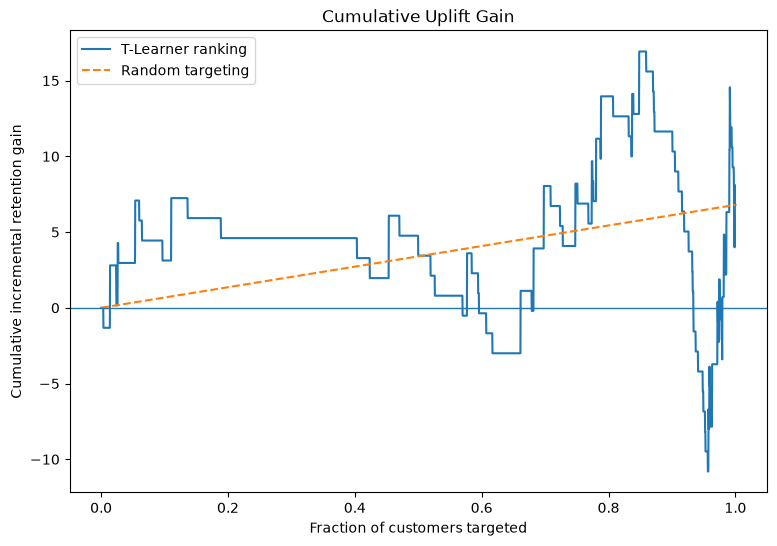

In [37]:
# plot cumulative gain curve
plt.figure(figsize=(9, 6))

plt.plot(
    eval_ranked["population_fraction"],
    eval_ranked["cumulative_gain"],
    label="T-Learner ranking"
)

plt.plot(
    eval_ranked["population_fraction"],
    eval_ranked["random_gain"],
    linestyle="--",
    label="Random targeting"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Fraction of customers targeted")
plt.ylabel("Cumulative incremental retention gain")
plt.title("Cumulative Uplift Gain")
plt.legend()

plt.show()

## Qini coefficient
positive Qini → ranking accumulates experimental benefit faster than random
near zero → little advantage over random
negative → ranking is worse than random overall

In [38]:
model_area = np.trapezoid(
    eval_ranked["cumulative_gain"],
    eval_ranked["population_fraction"]
)

random_area = np.trapezoid(
    eval_ranked["random_gain"],
    eval_ranked["population_fraction"]
)

qini_coefficient = model_area - random_area

print(f"Model cumulative area: {model_area:.4f}")
print(f"Random cumulative area: {random_area:.4f}")
print(f"Qini coefficient: {qini_coefficient:.4f}")

Model cumulative area: 4.5590
Random cumulative area: 3.3977
Qini coefficient: 1.1613


In [39]:
# calculate cumulative uplift itself
# gets us AUUC style curve expressed in actual treatemnt effectu units
eval_ranked["cumulative_uplift"] = (
    eval_ranked["uplift_signal"].cumsum()
    / np.arange(1, len(eval_ranked) + 1)
)

In [40]:
auuc_data = eval_ranked[
    eval_ranked["population_fraction"] >= 0.05
]

auuc = np.trapezoid(
    auuc_data["cumulative_uplift"],
    auuc_data["population_fraction"]
)

print(f"AUUC-style cumulative uplift area: {auuc:.6f}")

AUUC-style cumulative uplift area: 0.004813


In [42]:
overall_eval_retention_uplift = (
    eval_control_rate
    - eval_treatment_rate
)

print(
    f"Overall evaluation retention uplift: "
    f"{overall_eval_retention_uplift:.4f}"
)

Overall evaluation retention uplift: 0.0023


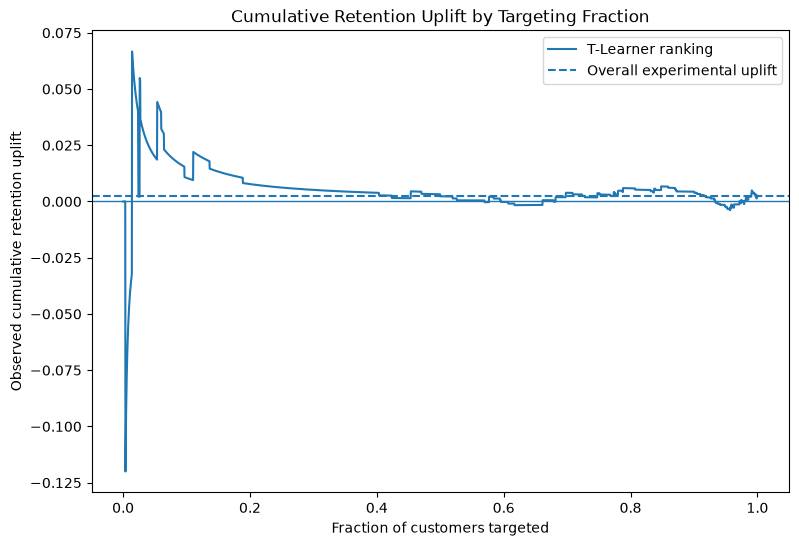

In [43]:
plt.figure(figsize=(9, 6))

plt.plot(
    eval_ranked["population_fraction"],
    eval_ranked["cumulative_uplift"],
    label="T-Learner ranking"
)

plt.axhline(
    overall_eval_retention_uplift,
    linestyle="--",
    label="Overall experimental uplift"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Fraction of customers targeted")
plt.ylabel("Observed cumulative retention uplift")
plt.title("Cumulative Retention Uplift by Targeting Fraction")
plt.legend()

plt.show()

### Cumulative uplift interpretation

The cumulative uplift curve is highly volatile at very small targeting fractions because only a small number of customers and churn events are included.

As more customers are added, the estimate becomes substantially more stable.

The T-Learner ranking shows periods of higher retention uplift than the overall experimental average, particularly near the top of the ranking, but the effect is not consistently monotonic.

Combined with the positive Qini coefficient, this suggests that the baseline T-Learner contains some useful treatment-response ranking signal, although the estimates remain noisy and should not be interpreted as precise individual treatment effects.

## T-Learner Baseline Findings

The calibrated logistic T-Learner provides the first heterogeneous treatment-effect baseline for the project.

Key findings:

- calibration substantially improved the stability of the two response models
- the highest predicted-uplift group showed positive observed treatment benefit
- individual quintile effects were noisy because churn events are rare
- cumulative targeting showed stronger uplift near parts of the top-ranked population than across the full population
- the cumulative gain curve achieved a **positive Qini coefficient of 1.161**
- the AUUC-style cumulative uplift area was **0.0048**

The ranking is not perfectly monotonic, and subgroup confidence intervals are wide. These results should therefore be interpreted as evidence of a potentially useful baseline rather than proof of accurately estimated individual treatment effects.

The next stage will compare this causal ranking with the previously trained churn-risk model and then evaluate whether more advanced heterogeneous treatment-effect estimators improve targeting quality.